# Scenario Data Generation and Visualization

Generate and visualize 500 synthetic observations per scenario. Each scenario uses the same true parameters but different noise realizations, allowing us to assess inference robustness.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from numpyro.infer import Predictive
from numpyro import handlers

import hx_models.heat_exchanger as hx
from hx_models.inference import (
    MODE_NAMES, p_to_z_mode, unpack_sim_for_SBI,
    PRIOR_LOG_BETA_F_MEAN, PRIOR_LOG_BETA_L_MEAN, PRIOR_LOG_LAMBDA_MEAN,
)
from hx_models.style import apply_paper_style, OBS_LABELS, SCENARIO_COLORS, TRUE_COLOR, save_fig

apply_paper_style()
np.random.seed(42)

## Configuration

In [2]:
USE_CACHED = True
N_REPEATS = 500
T = 100

PRIOR_MEDIAN_BETA_F = np.exp(PRIOR_LOG_BETA_F_MEAN)
PRIOR_MEDIAN_BETA_L = np.exp(PRIOR_LOG_BETA_L_MEAN)
PRIOR_MEDIAN_LAMBDA = np.exp(PRIOR_LOG_LAMBDA_MEAN)

SCENARIO_CONFIGS = {
    "scenario_1_normal_operation": {
        "T": T, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.005, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 5.0,
    },
    "scenario_2_batch_shutdown": {
        "T": T, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.03, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 0.5,
    },
    "scenario_3_boiler_feedwater": {
        "T": T, "tau": 18.0,
        "p": [0.0, 1.0, 0.0],
        "beta_f": 0.05, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": 3.0,
    },
    "scenario_4_mild_tube_leak": {
        "T": T, "tau": 18.0,
        "p": [0.0, 0.0, 1.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": 0.0005, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
    "scenario_5_severe_tube_leak": {
        "T": T, "tau": 18.0,
        "p": [0.0, 0.0, 1.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": 0.001, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
    "scenario_6_no_failure": {
        "T": T, "tau": 18.0,
        "p": [1.0, 0.0, 0.0],
        "beta_f": PRIOR_MEDIAN_BETA_F, "beta_l": PRIOR_MEDIAN_BETA_L, "lambda_rate": PRIOR_MEDIAN_LAMBDA,
    },
}

for cfg in SCENARIO_CONFIGS.values():
    cfg["z_mode"] = p_to_z_mode(cfg["p"])

SCENARIO_LABELS = ['Normal Op.', 'Batch SD', 'Boiler FW', 'Mild Leak', 'Severe Leak', 'No Failure']

obs_path = Path("../data/observations.npz")
configs_path = Path("../data/scenario_configs.csv")

print(f"N_REPEATS: {N_REPEATS}")
print(f"USE_CACHED: {USE_CACHED}")
for name, cfg in SCENARIO_CONFIGS.items():
    mode = MODE_NAMES[cfg['z_mode']]
    label = name.replace('scenario_', '').replace('_', ' ').title()
    print(f"  {label}: z_mode={cfg['z_mode']} ({mode})")

N_REPEATS: 500
USE_CACHED: True
  1 Normal Operation: z_mode=1 (fouling)
  2 Batch Shutdown: z_mode=1 (fouling)
  3 Boiler Feedwater: z_mode=1 (fouling)
  4 Mild Tube Leak: z_mode=2 (leak)
  5 Severe Tube Leak: z_mode=2 (leak)
  6 No Failure: z_mode=0 (none)


## Generate Observations

**Reproducibility note:** The observation generation uses `hash(scenario_name)` to derive per-repeat random seeds. Since `hash()` is randomized across sessions (controlled by `PYTHONHASHSEED`), re-generating observations in a new Python process will produce **different** data than the cached `observations.npz`. Statistical properties will be identical, but downstream metrics (CRPS, Wasserstein, etc.) will change because MCMC posteriors were computed on the original cached observations. Use `USE_CACHED = True` (the default) when running the full analysis pipeline.

In [3]:
if USE_CACHED and obs_path.exists():
    print(f"Loading cached observations from {obs_path}")
    cached = np.load(obs_path)
    all_obs = {name: cached[name] for name in SCENARIO_CONFIGS}
    print(f"Loaded {len(all_obs)} scenarios, {all_obs[list(all_obs)[0]].shape[0]} repeats each")
else:
    print("Generating observations...")
    all_obs = {}
    for scenario_name, config in SCENARIO_CONFIGS.items():
        T_sc = config["T"]
        tau01 = (config["tau"] - 1.0) / (T_sc - 2.0)
        
        condition_data = {
            "tau01": tau01,
            "p": jnp.array(config["p"]),
            "beta_f": config["beta_f"],
            "beta_l": config["beta_l"],
            "lambda_rate": config["lambda_rate"],
        }
        
        obs_list = []
        for i in range(N_REPEATS):
            seed = (abs(hash(scenario_name)) % 10000) * 1000 + i
            rng_key = jax.random.PRNGKey(seed)
            model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
            predictive = Predictive(model, num_samples=1)
            sim = predictive(rng_key, T=T_sc, hard_step=True)
            obs_flat = unpack_sim_for_SBI([sim]).squeeze(0).numpy()
            obs_list.append(obs_flat)
        
        all_obs[scenario_name] = np.stack(obs_list)
        print(f"  {scenario_name}: {all_obs[scenario_name].shape}")
    
    obs_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(obs_path, **all_obs)
    print(f"\nSaved to {obs_path}")

Loading cached observations from ../data/observations.npz
Loaded 6 scenarios, 500 repeats each


In [4]:
rows = []
for name, cfg in SCENARIO_CONFIGS.items():
    rows.append({
        "scenario": name,
        "label": name.replace('scenario_', '').replace('_', ' ').title(),
        "T": cfg["T"],
        "tau": cfg["tau"],
        "z_mode": cfg["z_mode"],
        "mode_name": MODE_NAMES[cfg["z_mode"]],
        "beta_f": cfg["beta_f"],
        "beta_l": cfg["beta_l"],
        "lambda_rate": cfg["lambda_rate"],
    })

configs_df = pd.DataFrame(rows)
configs_path.parent.mkdir(parents=True, exist_ok=True)
configs_df.to_csv(configs_path, index=False)
print("Scenario configurations:")
configs_df

Scenario configurations:


,scenario,label,T,tau,z_mode,mode_name,beta_f,beta_l,lambda_rate
0,scenario_1_normal_operation,1 Normal Operation,100,18.0,1,fouling,0.005,0.0004,5.0
1,scenario_2_batch_shutdown,2 Batch Shutdown,100,18.0,1,fouling,0.030,0.0004,0.5
2,scenario_3_boiler_feedwater,3 Boiler Feedwater,100,18.0,1,fouling,0.050,0.0004,3.0
3,scenario_4_mild_tube_leak,4 Mild Tube Leak,100,18.0,2,leak,0.015,0.0005,2.0
4,scenario_5_severe_tube_leak,5 Severe Tube Leak,100,18.0,2,leak,0.015,0.0010,2.0
5,scenario_6_no_failure,6 No Failure,100,18.0,0,none,0.015,0.0004,2.0


## Visualize Observations (500-Sample Envelope Plots)

Each plot shows the true signal, the spread of 500 noisy observations as a shaded band, and one representative sample.

In [5]:
def generate_true_signal(config, rng_seed=0):
    """Generate the true (noiseless) signal for a scenario."""
    T_sc = config["T"]
    tau01 = (config["tau"] - 1.0) / (T_sc - 2.0)
    condition_data = {
        "tau01": tau01,
        "p": jnp.array(config["p"]),
        "beta_f": config["beta_f"],
        "beta_l": config["beta_l"],
        "lambda_rate": config["lambda_rate"],
    }
    rng_key = jax.random.PRNGKey(rng_seed)
    model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
    predictive = Predictive(model, num_samples=1)
    sim = predictive(rng_key, T=T_sc, hard_step=True)
    
    sq = lambda x: np.asarray(x).squeeze()
    m_hot_out_t = sq(sim["m_hot_out_t"])
    UA_t = sq(sim["UA_t"])
    Th_out_true, Tc_out_true = hx.deterministic_outlet_temps(
        80.0, 25.0, m_hot_out_t, 2.0, 3500.0, 1900.0, UA_t)
    
    return {
        "time": np.arange(T_sc),
        "tau": float(sq(sim["tau"])),
        "Th_out_true": np.asarray(Th_out_true),
        "Tc_out_true": np.asarray(Tc_out_true),
        "m_hot_in_true": 2.0 * np.ones(T_sc),
        "m_hot_out_true": np.asarray(m_hot_out_t),
        "fouling_F": sq(sim["fouling_F_t"]),
        "leak_frac": sq(sim["leak_frac_t"]),
    }

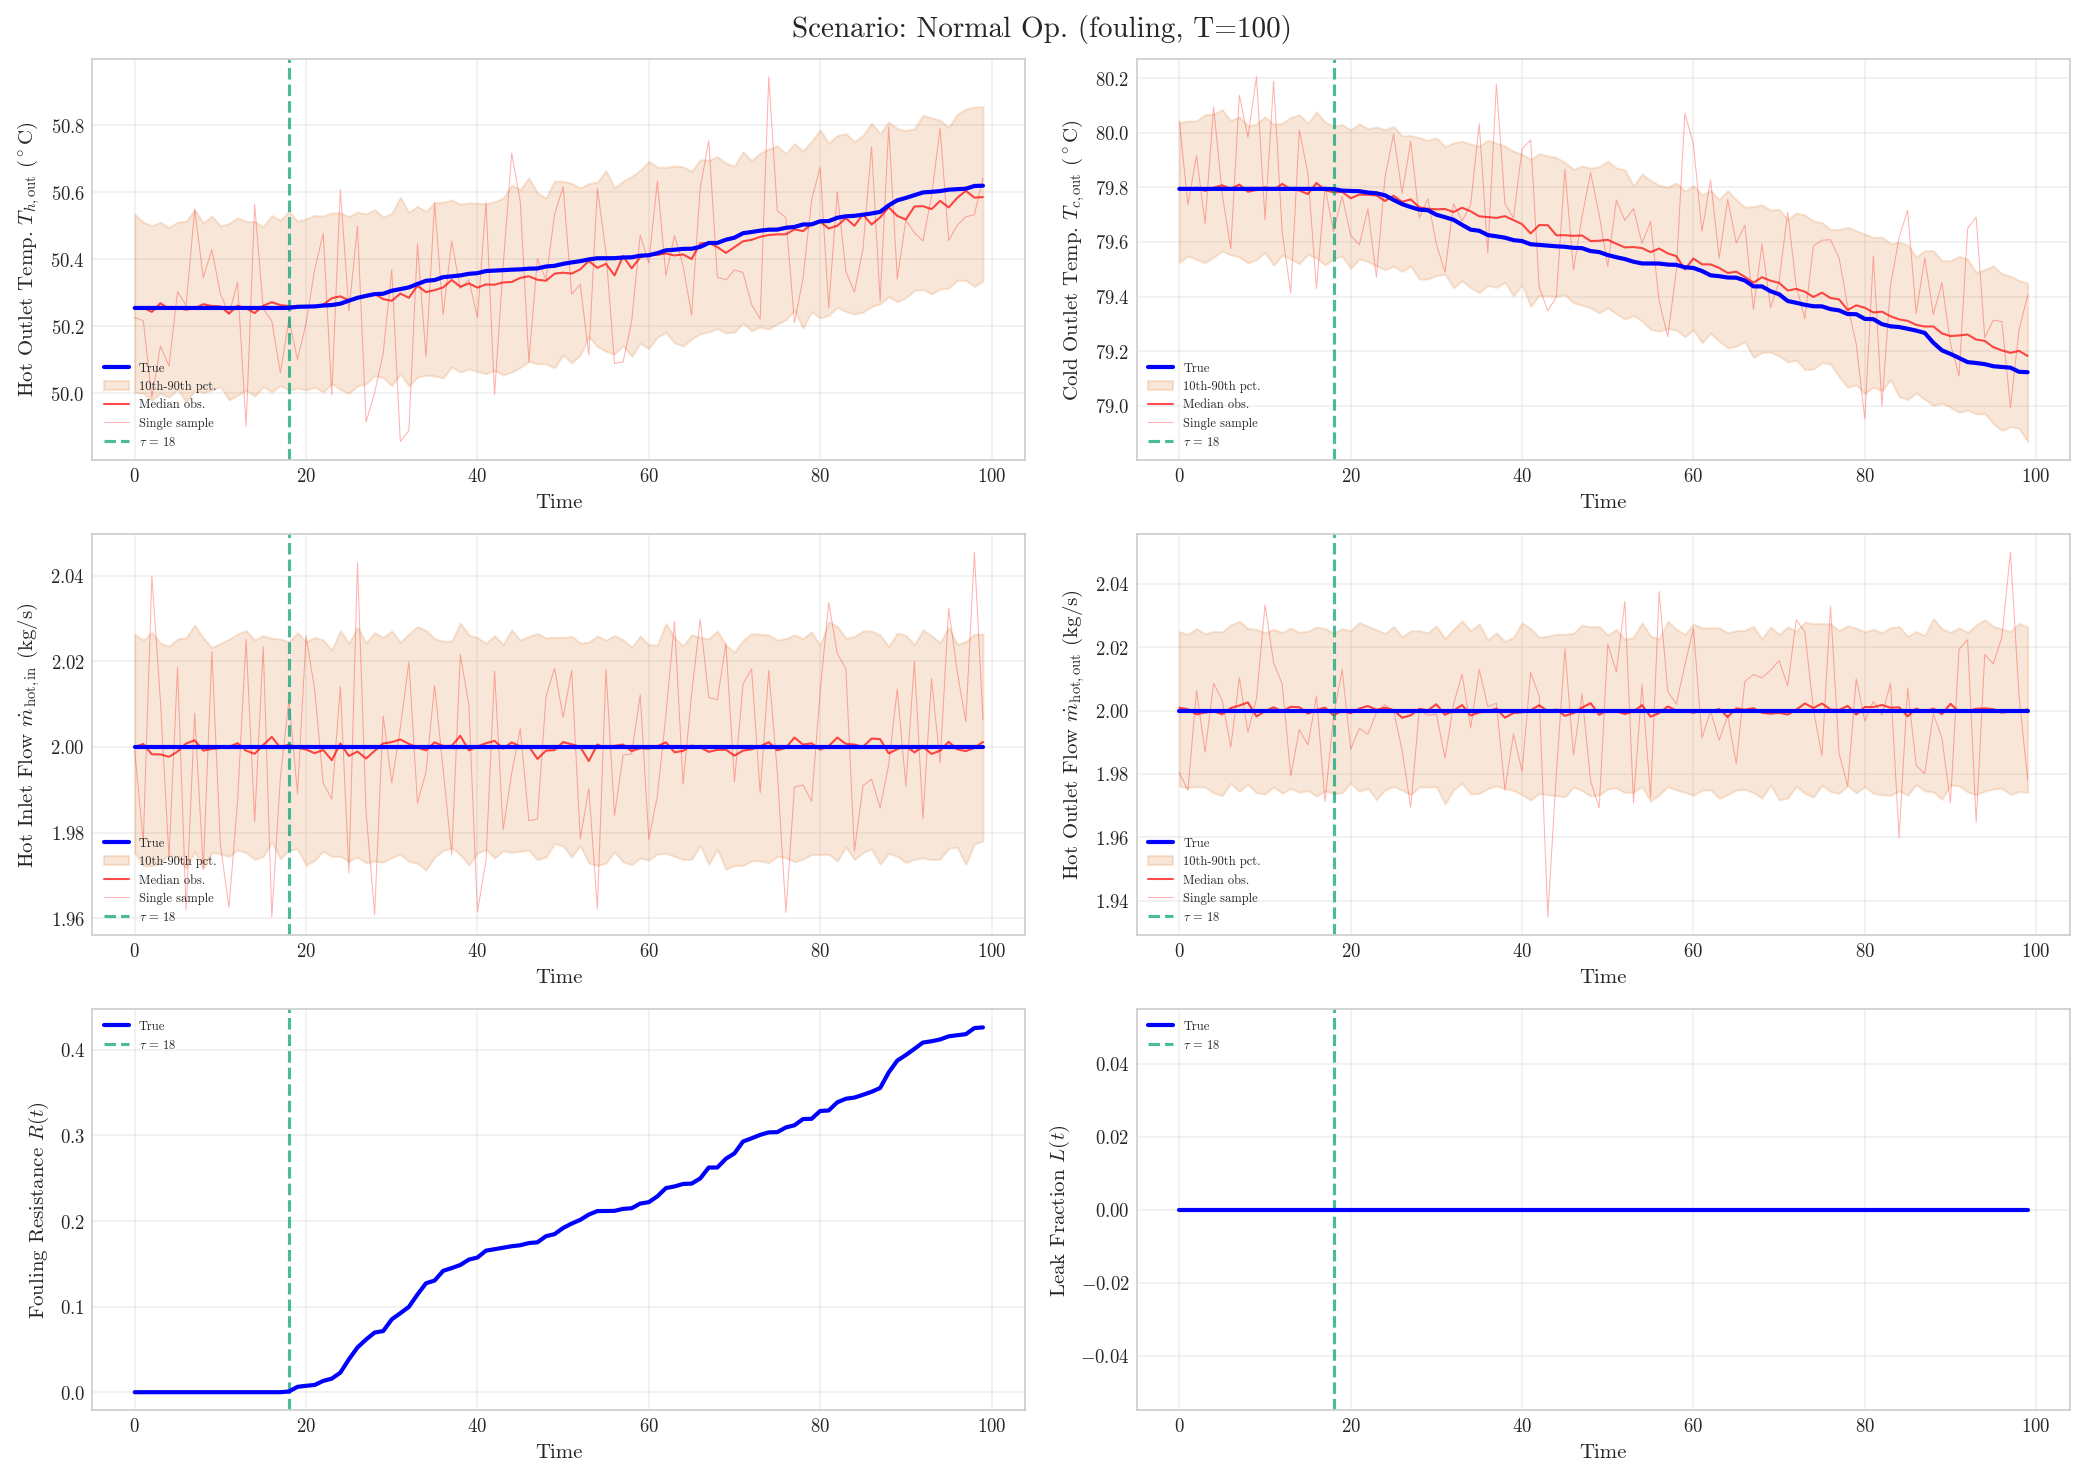

Saved: scenario_1_normal_operation


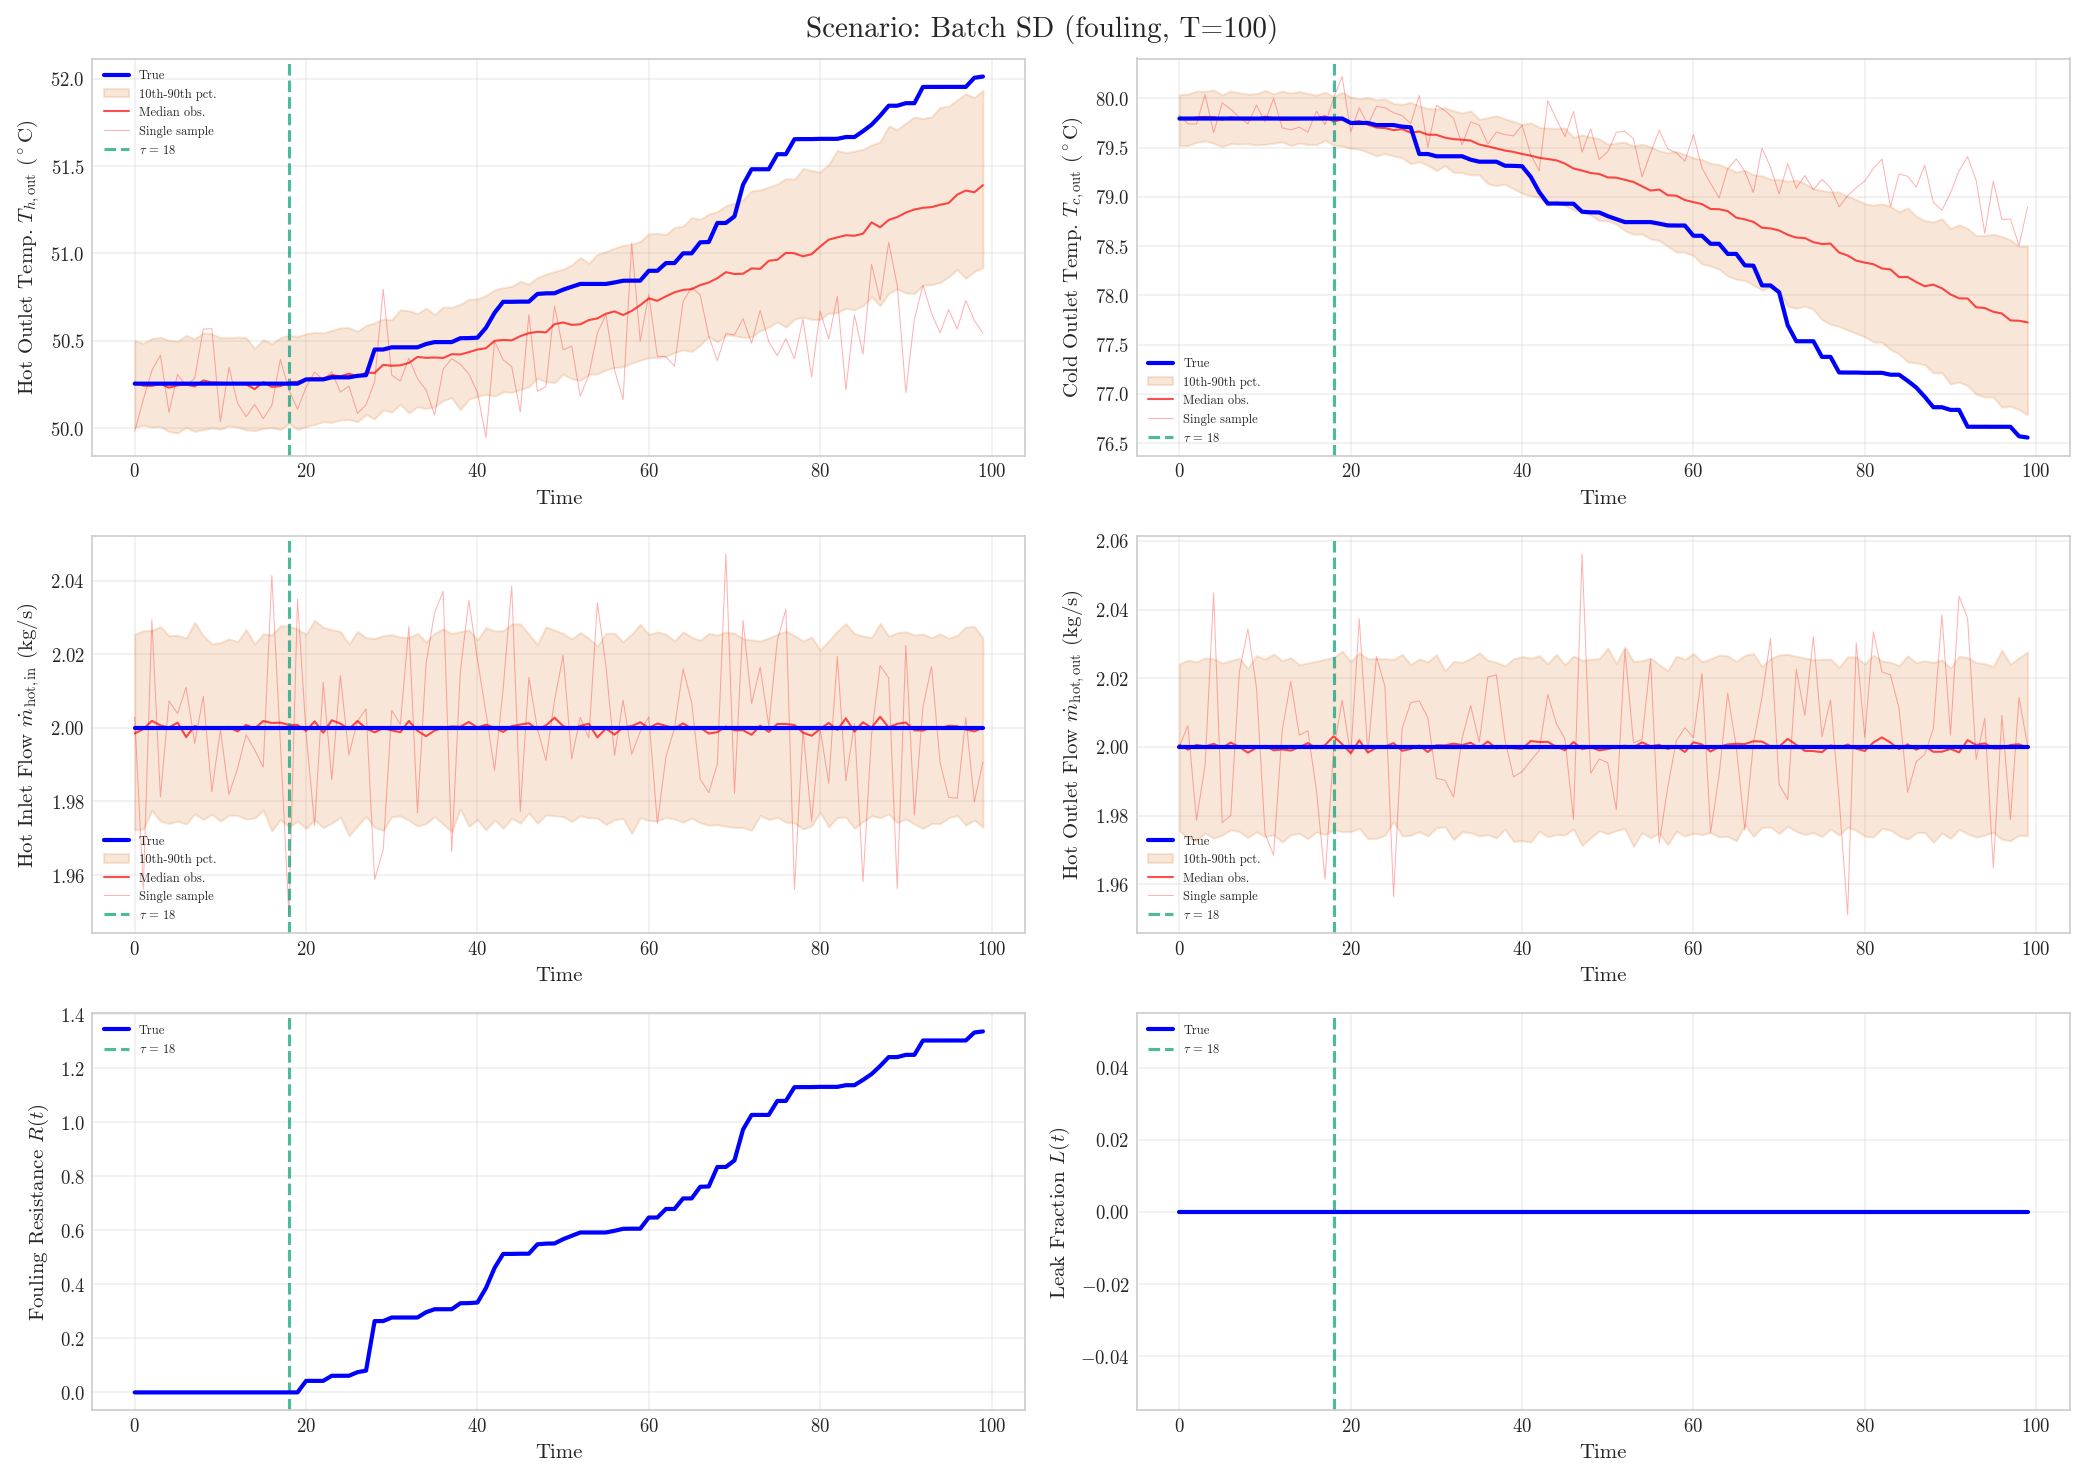

Saved: scenario_2_batch_shutdown


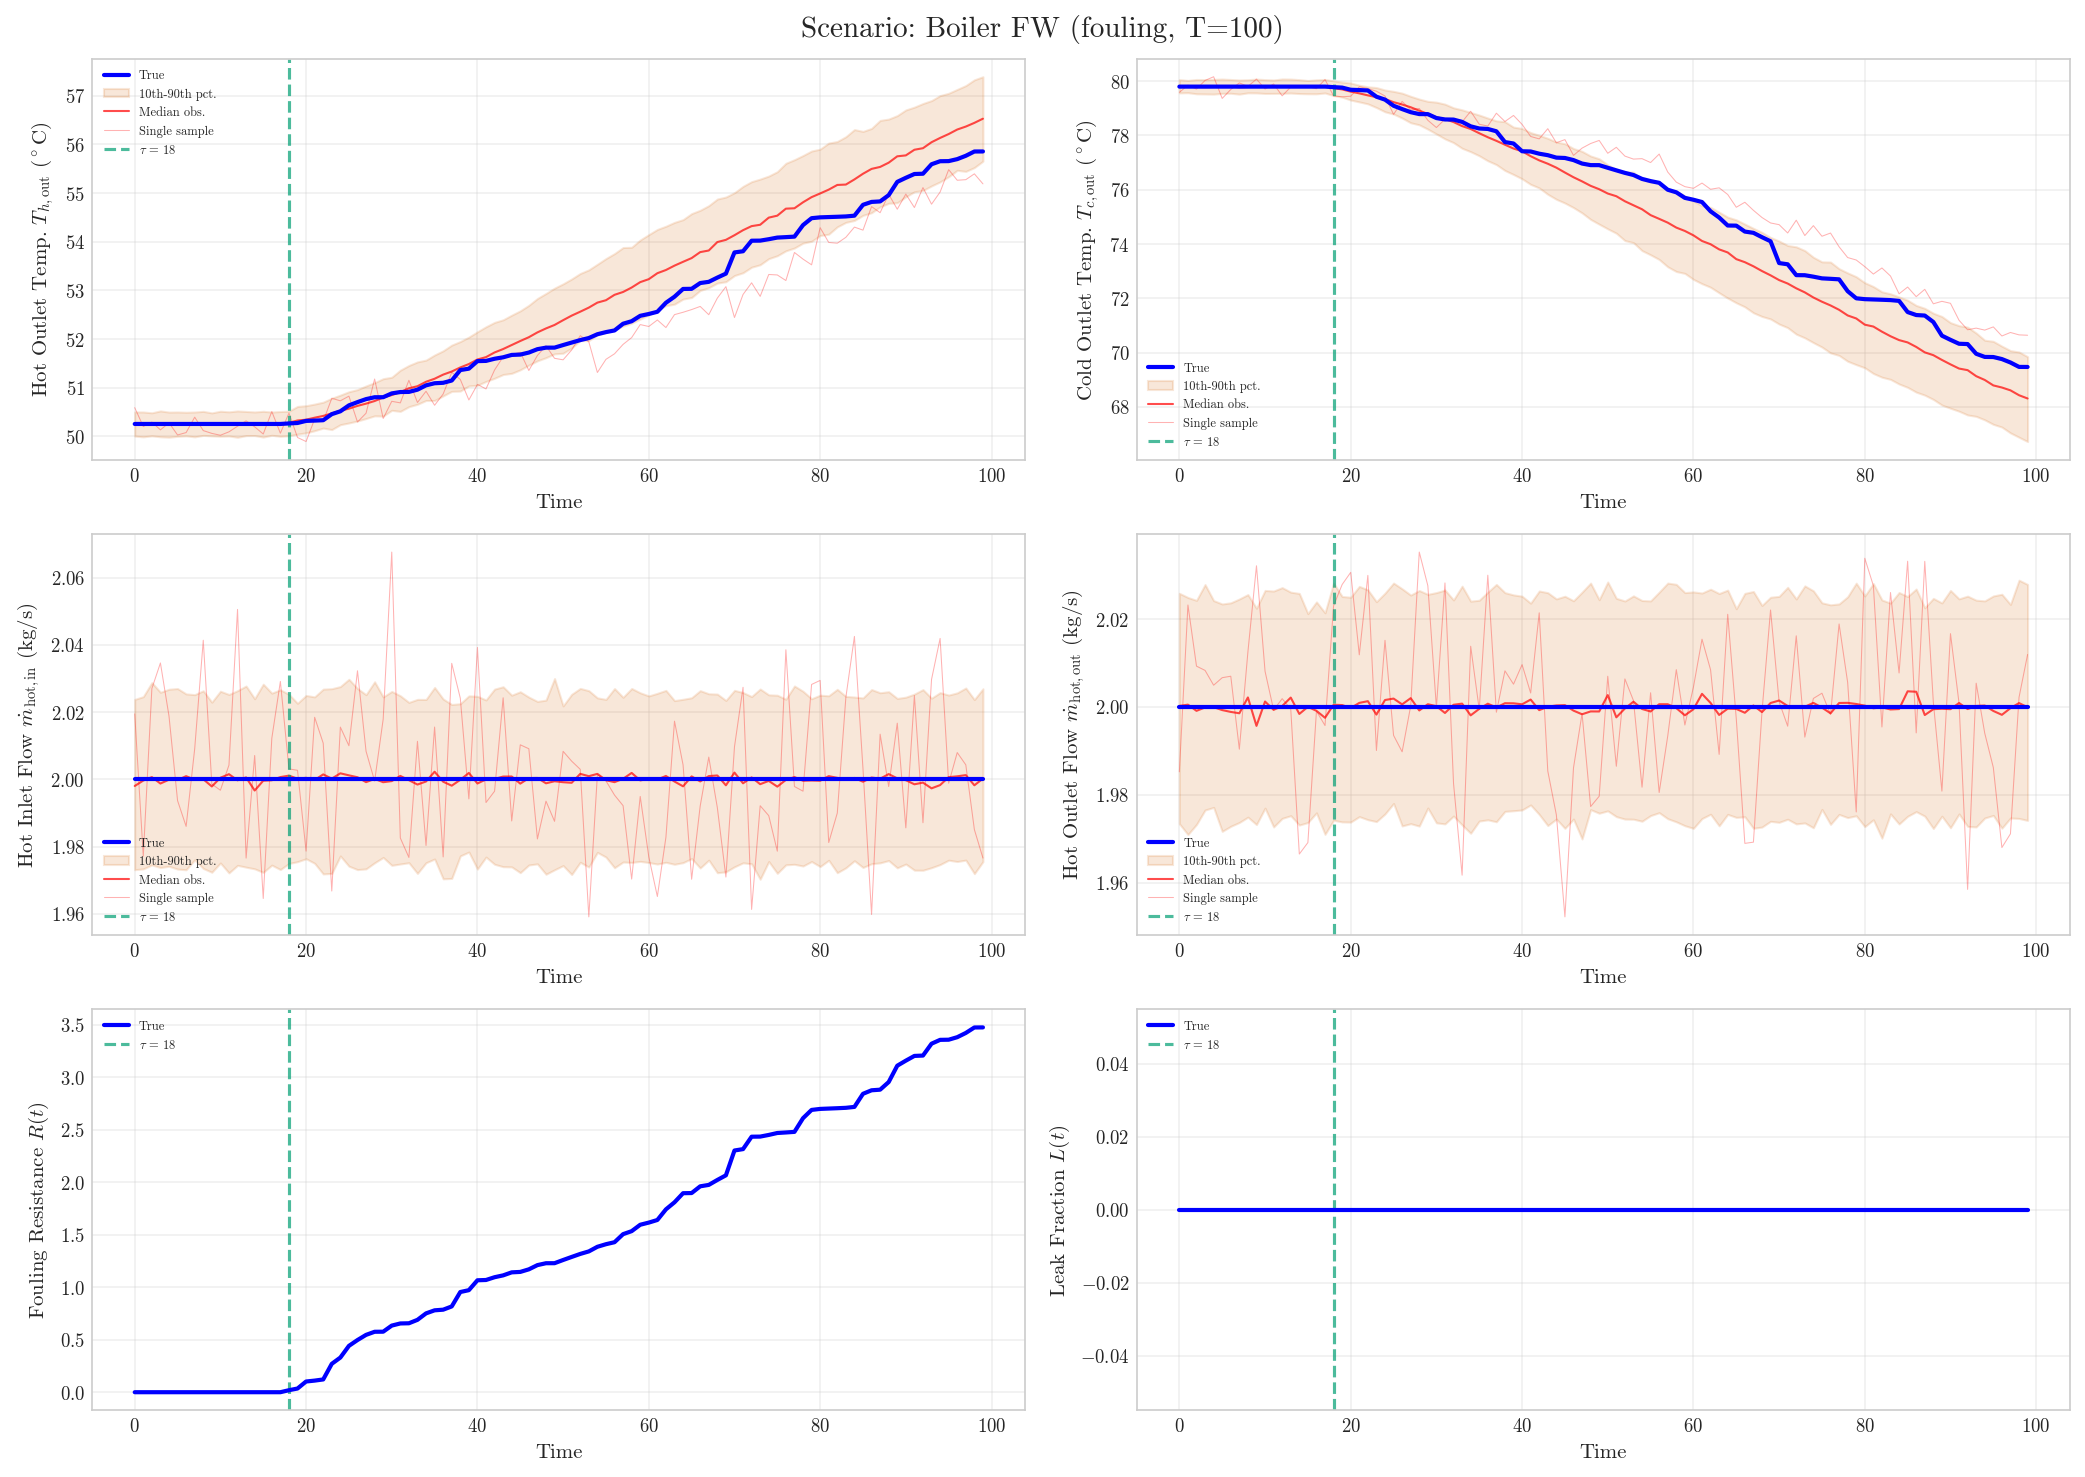

Saved: scenario_3_boiler_feedwater


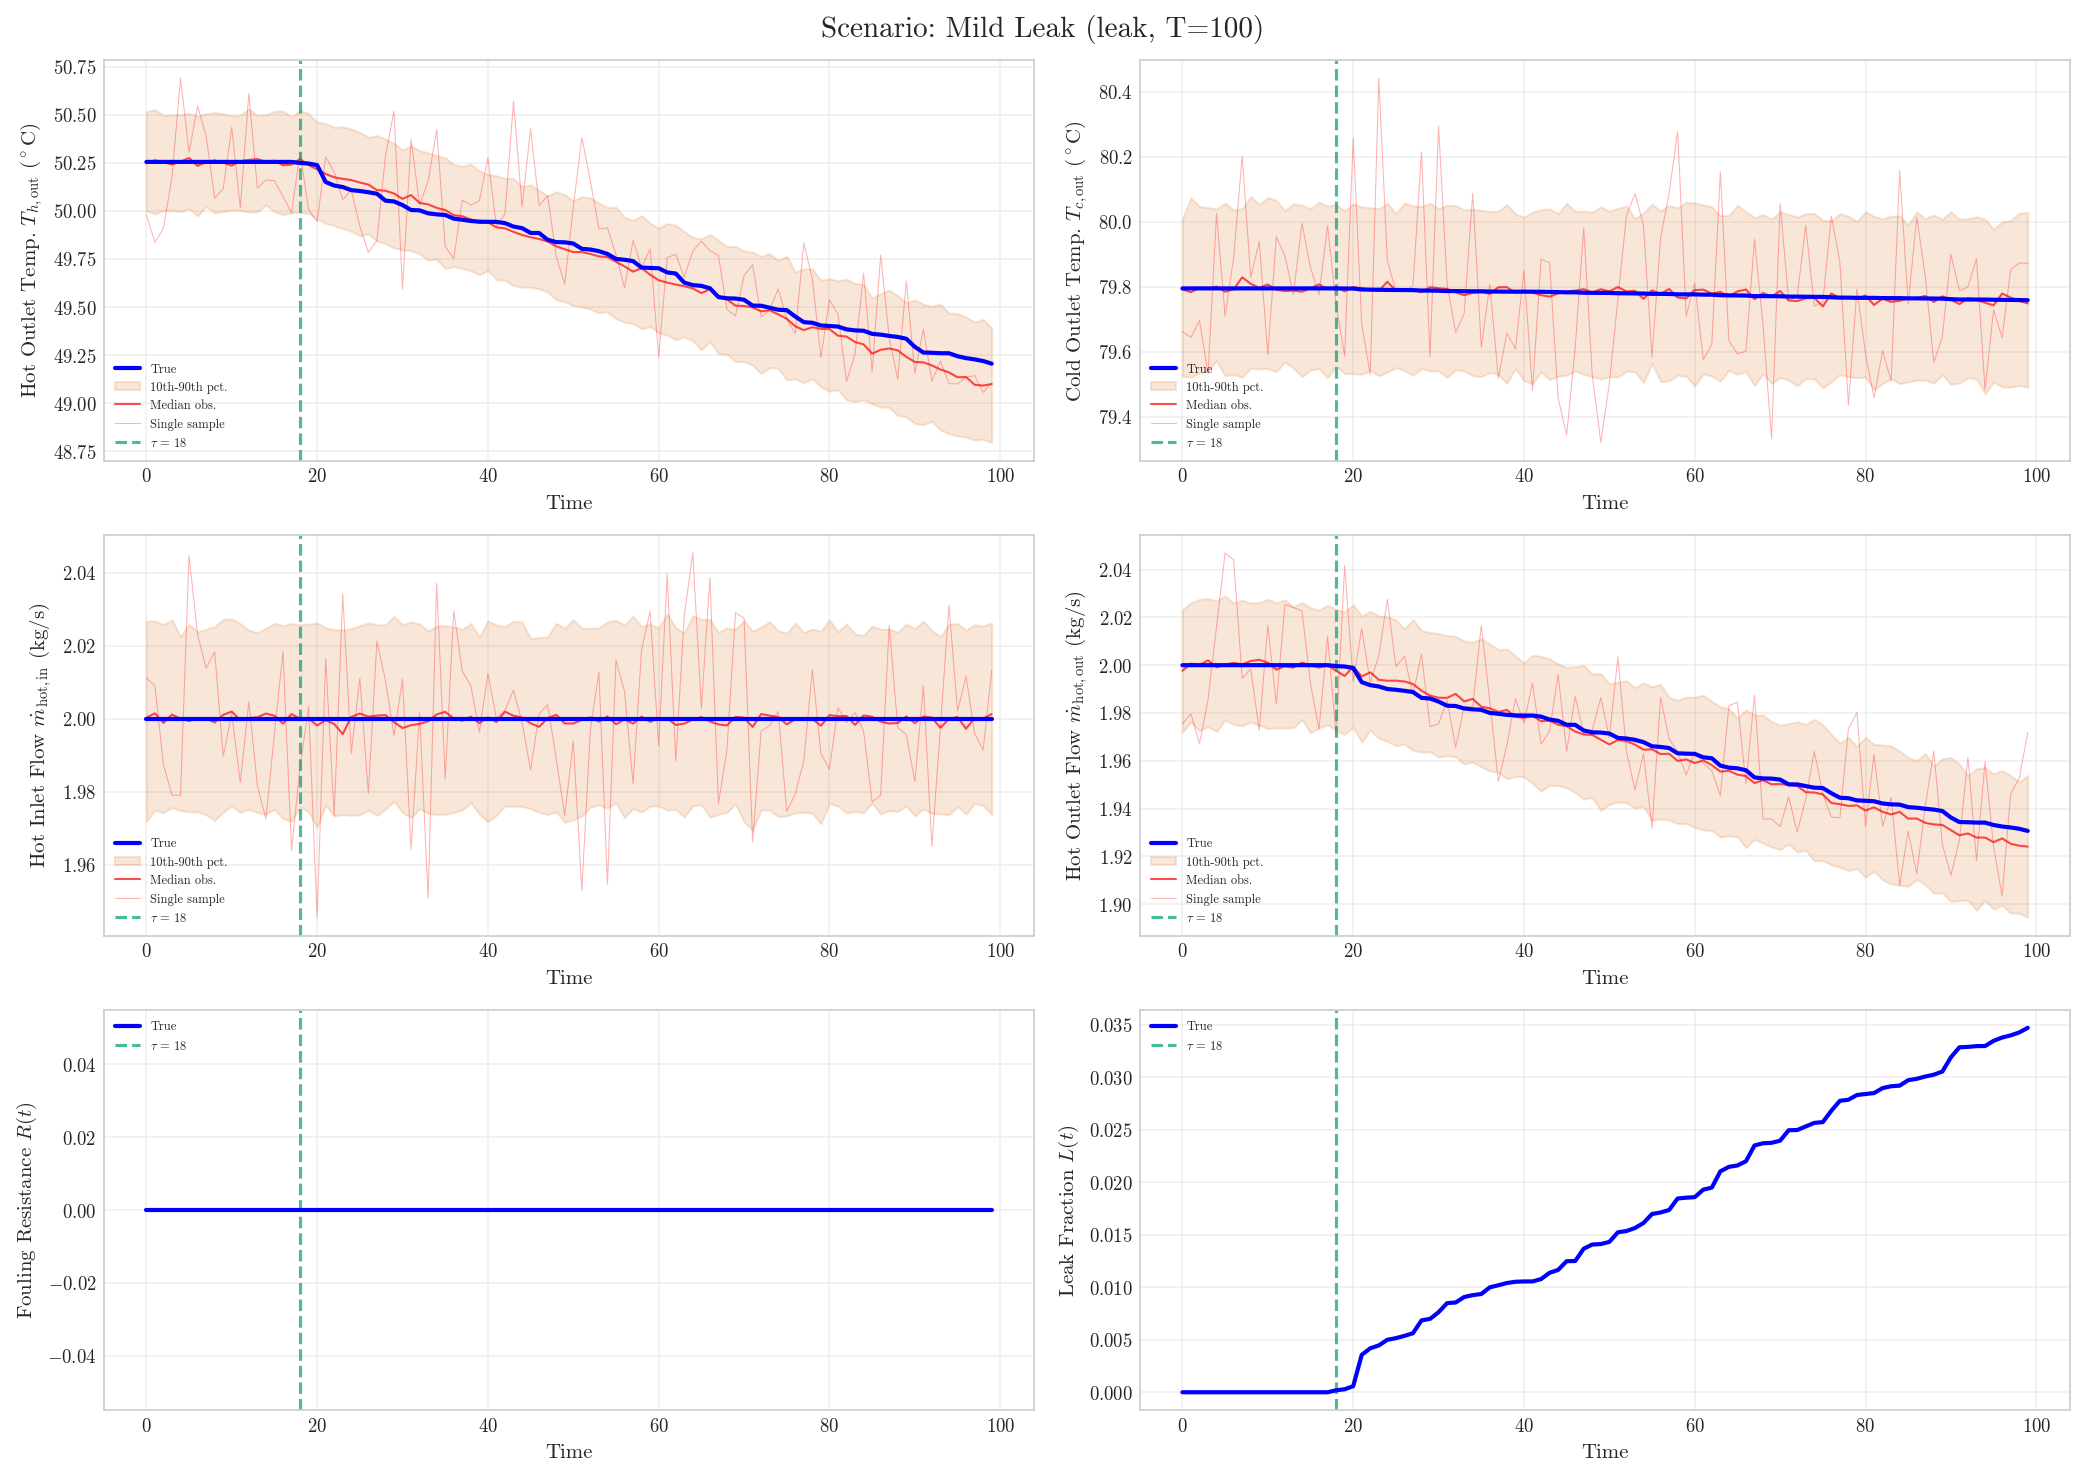

Saved: scenario_4_mild_tube_leak


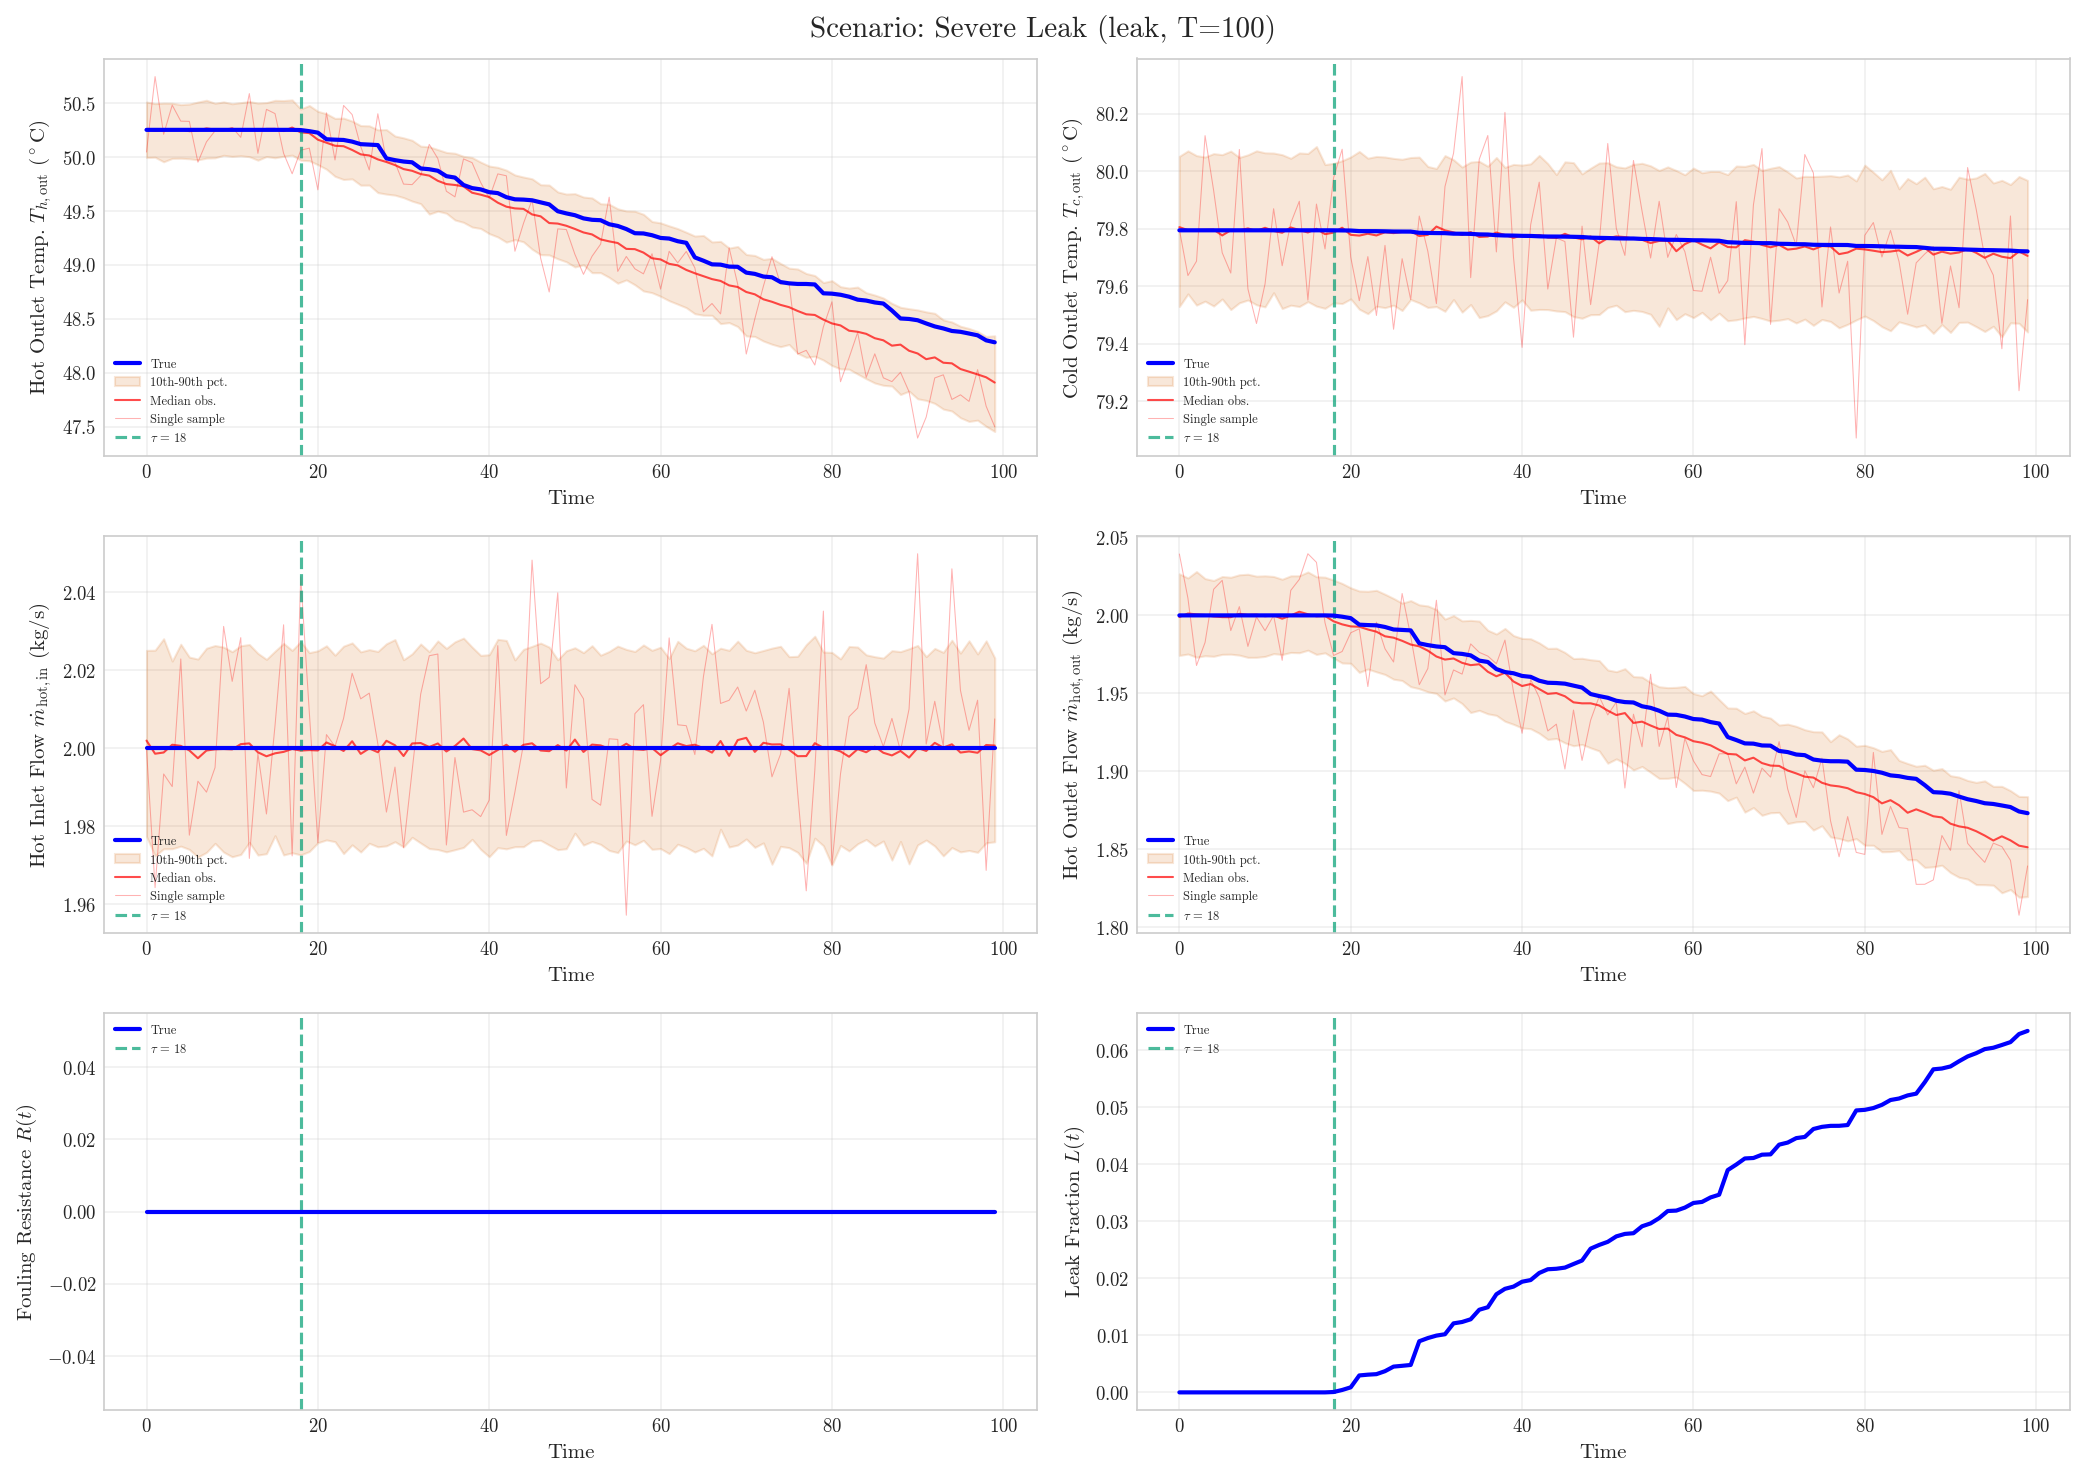

Saved: scenario_5_severe_tube_leak


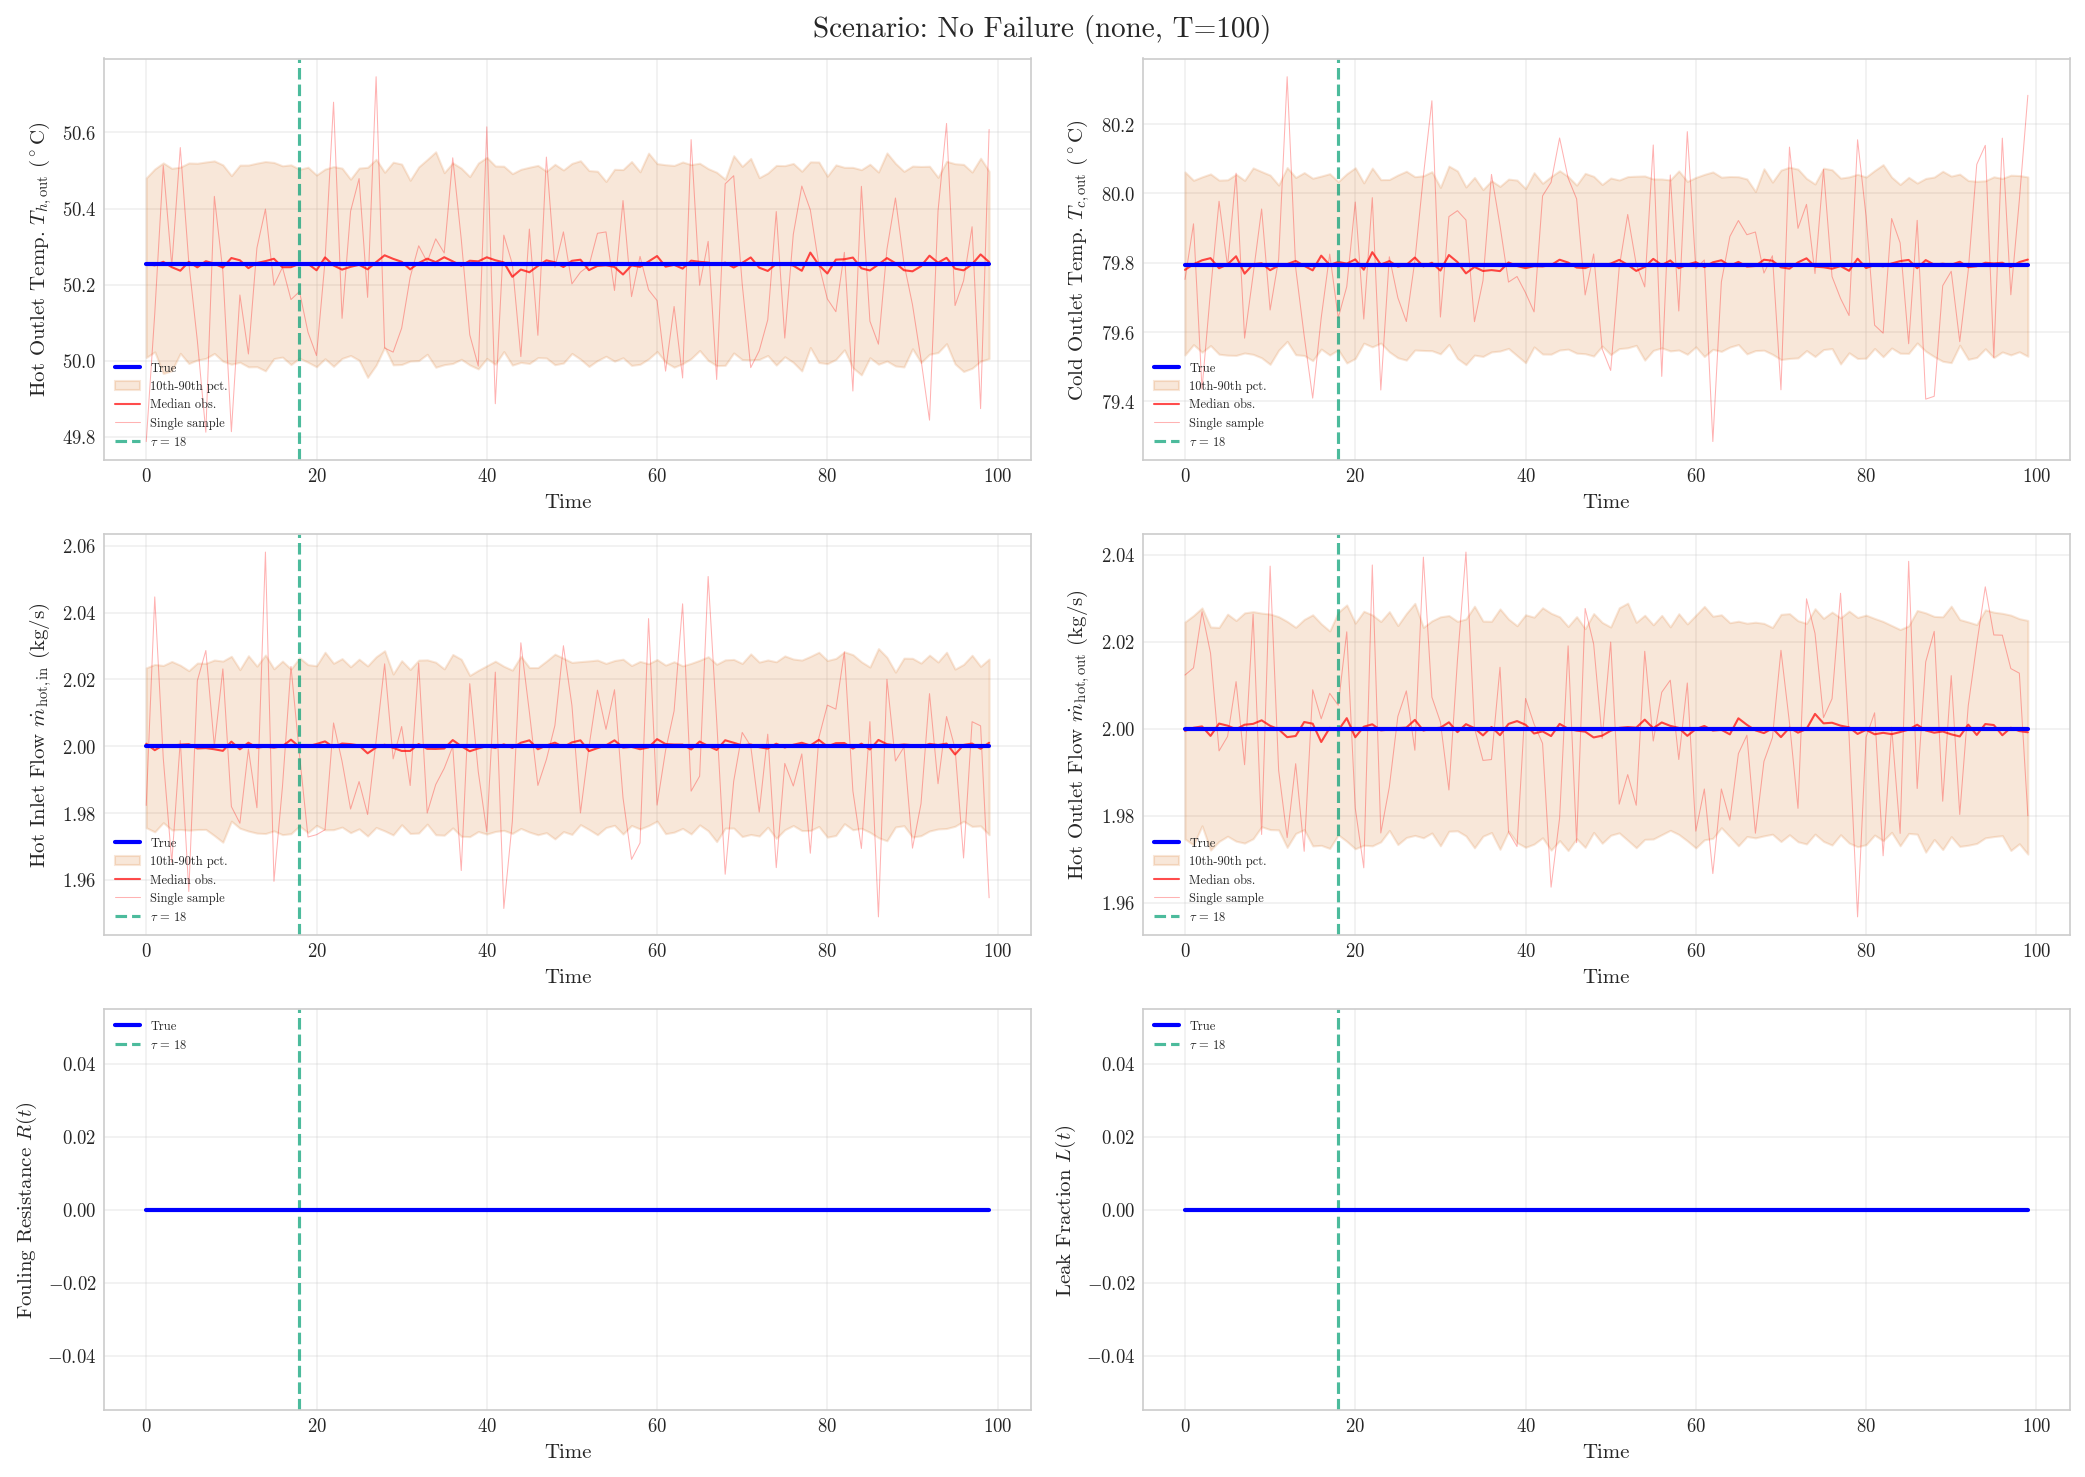

Saved: scenario_6_no_failure


In [6]:
plot_dir = Path("../figures")
plot_dir.mkdir(parents=True, exist_ok=True)

for i, (scenario_name, config) in enumerate(SCENARIO_CONFIGS.items()):
    T_sc = config["T"]
    tau_actual = config["tau"]
    mode = MODE_NAMES[config["z_mode"]]
    
    seed = (abs(hash(scenario_name)) % 10000) * 1000
    true_sig = generate_true_signal(config, rng_seed=seed)
    
    obs_all = all_obs[scenario_name]  # (500, 700)
    obs_reshaped = obs_all.reshape(N_REPEATS, 7, T_sc)  # (500, 7, T)
    # Channels: Th_in, Tc_in, Th_out, Tc_out, m_hot_in, m_hot_out, cond
    
    t = np.arange(T_sc)
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    
    panels = [
        (axes[0, 0], OBS_LABELS["Th_out"], true_sig["Th_out_true"], obs_reshaped[:, 2, :]),
        (axes[0, 1], OBS_LABELS["Tc_out"], true_sig["Tc_out_true"], obs_reshaped[:, 3, :]),
        (axes[1, 0], OBS_LABELS["m_hot_in"], true_sig["m_hot_in_true"], obs_reshaped[:, 4, :]),
        (axes[1, 1], OBS_LABELS["m_hot_out"], true_sig["m_hot_out_true"], obs_reshaped[:, 5, :]),
        (axes[2, 0], OBS_LABELS["fouling_F"], true_sig["fouling_F"], None),
        (axes[2, 1], OBS_LABELS["leak_frac"], true_sig["leak_frac"], None),
    ]
    
    for ax, ylabel, true_vals, obs_band in panels:
        ax.plot(t, true_vals, 'b-', lw=2, label='True', zorder=3)
        
        if obs_band is not None:
            p10 = np.percentile(obs_band, 10, axis=0)
            p50 = np.percentile(obs_band, 50, axis=0)
            p90 = np.percentile(obs_band, 90, axis=0)
            ax.fill_between(t, p10, p90, color=TRUE_COLOR, alpha=0.15, label='10th-90th pct.')
            ax.plot(t, p50, 'r-', lw=1, alpha=0.7, label='Median obs.')
            # One sample
            ax.plot(t, obs_band[0], 'r-', lw=0.5, alpha=0.3, label='Single sample')
        
        ax.axvline(tau_actual, color=SCENARIO_COLORS[2], ls='--', alpha=0.7, 
                   label=rf'$\tau$ = {tau_actual:.0f}')
        ax.set_xlabel('Time')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        if obs_band is None:
            legend_loc = 'upper left'
        elif ax is axes[0, 0] and scenario_name in (
            'scenario_2_batch_shutdown', 'scenario_3_boiler_feedwater',
        ):
            legend_loc = 'upper left'
        else:
            legend_loc = 'lower left'
        ax.legend(loc=legend_loc, fontsize=6)
    
    fig.suptitle(f'Scenario: {SCENARIO_LABELS[i]} ({mode}, T={T_sc})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig(fig, plot_dir / f"{scenario_name}_observations")
    plt.show()
    print(f"Saved: {scenario_name}")